# O25 Practical Code
Second attempt

# Practical 1 - Computing the Kaplan-Yorke Dimension

## Problem definition + Simulation
The Quasi-Static Spring Slider

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from tqdm import tqdm

## CONSTANTS

beta_1 = 1
beta_2 = 0.84
rho = 0.048

kappa_prime = 0.8544
kappa_cr_1 = beta_1 - 1
kappa_cr_2 = (
    kappa_cr_1 + rho*(2*beta_1 + (beta_2-1)*(2+rho)) + np.sqrt(
        4*rho**2 * (kappa_cr_1+beta_2) + (kappa_cr_1 + rho**2 * (beta_2-1))**2
    )
) / (2*(1+rho))

kappa = kappa_cr_2 * kappa_prime
v_0 = 1

## EOMS

def backup_func(t, input_vars):
    x, y, z = input_vars

    return (
        (-kappa * (np.exp(x) - v_0) + np.exp(x) * (
            x*(beta_1-1) + y - z
        ) + rho * np.exp(x) * (beta_2*x + z)),
        -kappa * (np.exp(x)-v_0),
        -rho*np.exp(x)*(
            beta_2*x+z
        )
    )

## alternate jacobian from lectures potentially instead?
#from scipy.differentiate import jacobian

## manual implementation
def jacobian(input_vars, kappa=kappa, beta_1=beta_1, beta_2=beta_2, rho=rho):

    assert len(input_vars) == 3

    x1, x2, x3 = input_vars

    ex = np.exp(x1)

    J11 = -kappa * ex + ex * (x1*(beta_1 - 1) + x2 - x3 + beta_1 - 1) + rho * ex * (beta_2 * x1 + x3 + beta_2)
    J12 = ex
    J13 = ex * (-1 + rho)

    J21 = -kappa * ex
    J22 = 0
    J23 = 0

    ## old version: J31 = -rho * ex * beta_2 * (x1 + 1)
    J31 = -rho * ex * (beta_2*x1 + x3 + beta_2)
    J32 = 0
    J33 = -rho * ex


    jac = np.array([
        [J11, J12, J13],
        [J21, J22, J23],
        [J31, J32, J33]
    ])

    return jac

#### Lorenz63 system

In [ ]:
sigma = 10
rho = 28
beta = 8/3

def lorenz63(t, X):
    
    x, y, z = X

    dx = sigma * (y-x)
    dy = x * (rho-z) - y
    dz = x*y - beta*z

    return (dx, dy, dz)

def lorenz_jac(t, X):

    x, y, z = X

    j1 = (-sigma, sigma, 0)
    j2 = (rho - z, -1, -x)
    j3 = (y, x, -beta)

    return np.array((j1, j2, j3))

def backup_func(t, X):
    return lorenz63(t, X)

def jacobian(X):
    return lorenz_jac(0, X)

### Part 1: Numerical Simulation

In [2]:
t_start = 0
t_transient = 400
t_end = 4000
dt = 0.01
t_eval = np.arange(t_start, t_end+dt, dt)
X_0 = [0.05, 0, 0]

soln = solve_ivp(backup_func, (t_start, t_end), X_0, t_eval=t_eval, method='Radau')

In [ ]:
n_points = 0

t = soln.t[-n_points:]
x, y, z = soln.y[:,-n_points:]

fig, ax = plt.subplots(3, 1, figsize=(15, 10))
ax = ax.flatten()

ax[0].plot(t, x)
ax[0].set_title('$x_1$')
ax[1].plot(t, y)
ax[1].set_title('$x_2$')
ax[2].plot(t, z)
ax[2].set_title('$x_3$')

ax_3d = fig.add_axes((0, -1, 1, 1), projection='3d')
ax_3d.plot(x, y, z)

ax_3d.set_xlabel('$x_1$')
ax_3d.set_ylabel('$x_2$')
ax_3d.set_zlabel('$x_3$')

ax_3d.set_title('Overall Motion')

fig.suptitle('Numerical Simulation of the Quasi-Static Spring Slider')

### Part 2: Calculating the Lyapunov Exponents

We need to evolve the basis vectors then perform QR renormalisation at each step, collecting the logarithm of the absolute values of the diagonals of R at each step

In [ ]:
def extended_func(t, input_vars, dt=0.1):

    assert len(input_vars) == 12 # 3 input vars (x1, x2, x3) + 9 basis vars (3x3 matrix representing 3 basis vectors) 

    X = input_vars[:3]
    flat_basis = input_vars[3:]

    basis = flat_basis.reshape(3, 3)

    dXdt = backup_func(t, X)
    J = jacobian(X)

    A = np.eye(3) + J * dt

    new_basis = A @ basis

    return np.concatenate([dXdt, new_basis.flatten()])

In [ ]:
from scipy.integrate import solve_ivp

t_start = 0
t_transient=400
t_end = 4000
dt = 0.1

t_eval = np.arange(t_transient, t_end, dt)
X_0 = [0.05, 0, 0]
initial_basis = np.eye(3)

intial_vars = np.concatenate([X_0, initial_basis.flatten()])

lyap_history = []
cur_vars = intial_vars

lyap_total = np.zeros(3)

for cur_time in tqdm(np.arange(t_start, t_end, dt)):

    soln = solve_ivp(extended_func, (cur_time, cur_time+dt), cur_vars, method='RK45', rtol=1e-8, atol=1e-10)

    cur_vars = soln.y[:,-1]

    ## lyapunov collecting step
    cur_basis = cur_vars[3:].reshape(3, 3)

    Q, R = np.linalg.qr(cur_basis)

    new_basis = Q

    if cur_time >= t_transient:
        ## the r_ii values (the amount the bases stretch by)
        stretch = np.diag(R)

        ## collect Lyapunov exponents after the transient
        lyap_total += np.log(np.abs(stretch))

        lyap_exponents = np.log(np.abs(stretch)) / cur_time

        lyap_history.append(lyap_exponents)

        ## set the basis vectors to the orthogonal ones
        cur_vars[3:] = Q.flatten()        

print(lyap_total)

In [ ]:
from scipy.integrate import solve_ivp

t_start = 0
t_transient=4000
t_end = 10000
dt = 0.1

t_eval = np.arange(t_transient, t_end, dt)
X_0 = [0.05, 0, 0]
initial_basis = np.eye(3)

intial_vars = np.concatenate([X_0, initial_basis.flatten()])

lyap_history = []
cur_vars = intial_vars

lyap_total = np.zeros(3)

for cur_time in tqdm(np.arange(t_start, t_end, dt)):

    soln = solve_ivp(extended_func, (cur_time, cur_time+dt), cur_vars, method='RK45', rtol=1e-8, atol=1e-10)

    cur_vars = soln.y[:,-1]

    ## lyapunov collecting step
    cur_basis = cur_vars[3:].reshape(3, 3)

    Q, R = np.linalg.qr(cur_basis)

    new_basis = Q

    if cur_time >= t_transient:
        ## the r_ii values (the amount the bases stretch by)
        stretch = np.diag(R)

        ## collect Lyapunov exponents after the transient
        lyap_total += np.log(np.abs(stretch))

        lyap_exponents = np.log(np.abs(stretch)) / cur_time

        lyap_history.append(lyap_exponents)

        ## set the basis vectors to the orthogonal ones
        cur_vars[3:] = Q.flatten()        

print(lyap_total)

In [ ]:
lyap_total / t_end

In [ ]:
b = [[float(j) for j in list(i)] for i in lyap_history]

with open('exponents.txt', 'w') as outfile:
    outfile.write(repr(b))

In [ ]:
import matplotlib.pyplot as plt

a = np.array(lyap_history).T
final_le = a.sum(axis=1)

2+final_le[0]+final_le[1] / abs(final_le[2])

### Part 2.1: New Attempt -- Exponent from pre-computed system

In [ ]:
X = soln.y.T
t = soln.t

le_history = []

le_total = np.zeros(3)

initial_basis = np.eye(3)

V = initial_basis

for t_id in tqdm(range(len(t))):

    cur_time = t[t_id]
    cur_posn = X[t_id]

    if cur_time >= t_transient:

        dt = t[t_id] - t[t_id - 1]


        cur_time = t[t_id]
        cur_posn = X[t_id]

        jac = jacobian(cur_posn)

        A = np.eye(3) + jac * dt

        V_prime = A @ V

        Q, R = np.linalg.qr(V_prime)

        V = Q.copy()

        ## record lyapunov exponents
        R_diagonals = np.diag(R)

        le_current = np.log(np.abs(R_diagonals))

        le_total += le_current
        
        le_history.append(le_total.copy())

lyapunov_final = le_total / (t[-1] - t_transient)
lyapunov_final

In [ ]:
lya

In [ ]:
l1, l2, l3 = np.transpose(le_history)

plt.plot(l1, label='Lyapunov 1')
plt.plot(l2, label='Lyapunov 2')
plt.plot(l3, label='Lyapunov 3')
plt.legend()

In [ ]:
le_total / t[-1]

In [ ]:
current_le = np.zeros(3)

cumulative_le = []

for i in tqdm(range(len(le_history))):
    current_le += le_history[i]

    cumulative_le.append(current_le.copy())

In [ ]:
x, y, z = np.transpose(le_history)

plt.plot(t[40000::], x)


In [ ]:
final_le = lyapunov_final
final_le

In [ ]:
print(f'Two sum: {sum(final_le[:-1])}')
print(f'Three sum: {sum(final_le)}')
print(f'Kaplan-Yorke Dimension: {2+(final_le[0]+final_le[1])/np.abs(final_le[2])}')

# Section 2 -- Practical 2 (Correlation Dimension)
The aim is literally to calculate the Correlation dimension. The steps given are:

1. Implement the Theiler window 'using the first zero of the autocorrelation of one time series (eg x)'
2. Calculate the correlation sum, C($\varepsilon$) for various $\varepsilon$ to 'cover the attractor and get a scaling region'
3. Evaluate the correlation $D_\text{corr}$ from the slope of the log(C($\varepsilon$)) vs log($\varepsilon$)

It then asks us to consider:
1. How do the Correlation and Kaplan-Yorke dimensions compare?
2. How does the Correlation dimension change with or without the Theiler window?
3. How do the dimensions change if we change the length of the trajectory? Or the sampling rate?

## Part 1: Implementing the Theiler Window

### Finding the window size

[ 830 2535 4244 5935 7596 9110]
[ 889 2622 4336 6076 7841 9998]
[ 892 2631 4341 6091 7867 9998]


'First zero of autocorrelation function: 830'

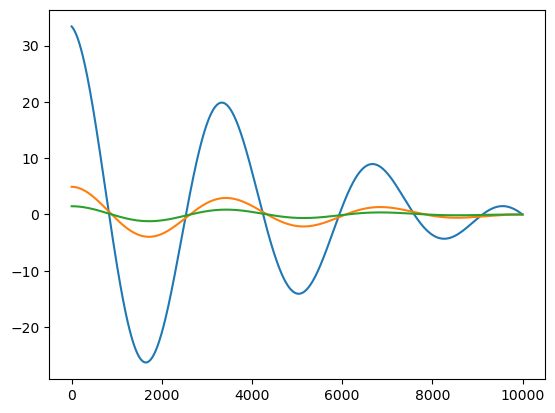

In [35]:
def autocorrelation(arr, num_pts = 10000):
    '''
    Returns array of autocorrelation for an array
    '''

    corr = np.correlate(arr[:num_pts], arr[:num_pts], mode='full')

    return corr[num_pts-1:]

def sign_changes(arr):
    '''
    Returns indices before sign changes
    '''

    return np.where(np.diff(np.sign(arr)))[0]

x1, x2, x3 = soln.y

ac1 = autocorrelation(x1)
ac2 = autocorrelation(x2)
ac3 = autocorrelation(x3)

plt.plot(ac1)
plt.plot(ac2)
plt.plot(ac3)

z1 = sign_changes(ac1)
z2 = sign_changes(ac2)
z3 = sign_changes(ac3)

print(z1)
print(z2)
print(z3)

## choose first zero of the x window
FIRST_ZERO = min(z1[0], z2[0], z3[0])
display(f'First zero of autocorrelation function: {FIRST_ZERO}')

## Part 2: The Correlation Sum
We now wish to implement a Theiler window of size `window_size` to calculate the Correlation sum

In [41]:
## correlation sum

eps = 0.1
window_size = FIRST_ZERO

t = soln.t
timestep = t[1] - t[0]

pts = soln.y.T ### points in a (n_pts, n_dims) shape

def correlation_sum(eps, data, window = window_size):
    '''
    calculates the correlation sum, C(eps) assuming `data` is all the points up to and including time T with a Theiler window of size `window`
    '''

    ## assert data is 3-dimensional and in the correct orientation
    assert data.shape[1] == 3, 'Incorrect dimensions; data should be in shape `(n_points, n_dimensions)` // n_dimensions currently must be 3'


    T = data.shape[0]

    scale_factor = 2 / ((T - window) * (T - window - 1))

    neighbours = 0

    for i in tqdm(range(T - window - 1)):
        x_i = data[i]

        for j in range(1 + window + i, T):
            x_j = data[j]

            dist = np.linalg.norm(x_i - x_j)

            if dist < eps:
                neighbours += 1

    return scale_factor * neighbours

test_set = pts[:10000]

correlation_sum(eps, test_set)

100%|██████████| 9169/9169 [05:09<00:00, 29.63it/s] 


np.float64(0.6696726785397622)